In [5]:
# Cell 2: Install packages (run if packages missing)
# If running on Colab or fresh environment, uncomment the pip installs below.

# !pip install --upgrade pip
# !pip install pillow matplotlib numpy pandas scikit-learn tensorflow tensorflow-addons

# If already installed, you can skip installs.

import importlib, sys
print("Python", sys.version.splitlines()[0])


Python 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


In [6]:
# Cell 3: imports
import os
import random
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance, ImageOps
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support
import tensorflow_addons as tfa  # optional, used only if you enable focal loss

print("TensorFlow", tf.__version__)


TensorFlow 2.13.0


In [7]:
# Cell 5: parameters and reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "data"       # where dataset will live
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 10           # shorter for quick demo; increase for real training
FINE_TUNE_EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE
BACKBONE = 'EfficientNetB0'


In [8]:
# Cell 7: utility functions (image ops, plotting, overlay, CLAHE alternative)
from typing import Tuple

def pil_open(path):
    return Image.open(path).convert("RGB")

def resize_pil(img: Image.Image, size: Tuple[int,int]):
    return img.resize(size, Image.BILINEAR)

def show_img(img, title=None):
    plt.imshow(np.asarray(img).astype('uint8'))
    if title:
        plt.title(title)
    plt.axis('off')

def plot_grid(imgs, titles=None, cols=4, size=(3,3)):
    n = len(imgs)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(size[0]*cols, size[1]*rows))
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i+1)
        show_img(im, None if not titles else titles[i])
    plt.tight_layout()
    plt.show()

# Simple global equalization using PIL (not CLAHE but helps contrast)
def equalize_pil(img: Image.Image) -> Image.Image:
    return ImageOps.equalize(img)

# Create a heatmap overlay without cv2 using matplotlib colormap and PIL blending
import matplotlib.cm as cm

def overlay_heatmap_pil(image: Image.Image, heatmap: np.ndarray, alpha=0.4):
    """
    image: PIL RGB image
    heatmap: 2D numpy array with values in [0,1]
    """
    h, w = image.size[1], image.size[0]
    # Normalize and map to colormap
    heat_norm = np.clip(heatmap, 0.0, 1.0)
    cmap = cm.get_cmap("jet")
    heat_rgba = cmap(heat_norm)[:, :, :3]  # HxWx3 floats
    # Convert heatmap to PIL Image
    heat_img = Image.fromarray((heat_rgba * 255).astype('uint8')).resize((w,h), resample=Image.BILINEAR)
    # Blend
    blended = Image.blend(image, heat_img, alpha=alpha)
    return blended


In [9]:
# Cell 9: generate synthetic dataset
def draw_rbc(draw, center, radius, fill=(220,180,180), outline=(120,60,60)):
    x,y = center
    bbox = [x-radius, y-radius, x+radius, y+radius]
    draw.ellipse(bbox, fill=fill, outline=outline)

def add_parasite(draw, center, radius, color=(180,0,0)):
    x,y = center
    # small offset inside the RBC
    dx = random.randint(-radius//3, radius//3)
    dy = random.randint(-radius//3, radius//3)
    r = max(2, radius//6)
    draw.ellipse([x+dx-r, y+dy-r, x+dx+r, y+dy+r], fill=color)

def make_image(img_size=(224,224), infected=False):
    W, H = img_size
    img = Image.new("RGB", (W,H), (245,245,245))
    draw = ImageDraw.Draw(img)
    # RBC center roughly center with jitter
    cx = W//2 + random.randint(-10,10)
    cy = H//2 + random.randint(-10,10)
    radius = min(W,H)//3 + random.randint(-8,8)
    # Randomize cell color a bit
    base = (random.randint(200,235), random.randint(160,200), random.randint(160,200))
    draw_rbc(draw, (cx,cy), radius, fill=base, outline=(120,80,90))
    # Add small artifacts / noise
    if random.random() < 0.3:
        # light dot
        dx = random.randint(10,W-10)
        dy = random.randint(10,H-10)
        draw.ellipse([dx-2,dy-2,dx+2,dy+2], fill=(200,200,200))
    if infected:
        add_parasite(draw, (cx,cy), radius, color=(180,0,0))
    # Slight blur to mimic microscope
    img = img.filter(ImageFilter.GaussianBlur(radius=0.7))
    # Slight contrast adjust
    img = ImageEnhance.Contrast(img).enhance(1.05)
    return img

def generate_dataset(root="data_synthetic", n_per_class=200, img_size=IMG_SIZE):
    root = Path(root)
    for split in ("train","val","test"):
        for cls in ("healthy","infected"):
            dirp = root / split / cls
            dirp.mkdir(parents=True, exist_ok=True)
    # ratios for splits
    for cls, infected in [("healthy", False), ("infected", True)]:
        for i in range(n_per_class):
            img = make_image(img_size=img_size, infected=infected)
            # decide split
            r = random.random()
            if r < 0.7:
                split = "train"
            elif r < 0.85:
                split = "val"
            else:
                split = "test"
            # name & save
            outdir = Path("data_synthetic") / split / cls
            outpath = outdir / f"{cls}_{i:04d}.png"
            img.save(outpath)
    return Path("data_synthetic")

# generate small dataset
synthetic_root = generate_dataset(root="data_synthetic", n_per_class=300)
print("Synthetic dataset created at:", synthetic_root)


Synthetic dataset created at: data_synthetic


In [10]:
# Cell 12: set data dir to synthetic dataset for now
DATA_DIR = "data_synthetic"   # change to your dataset path when available
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Val dir exists:", os.path.exists(VAL_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

# use image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', seed=SEED, shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Train dir exists: True
Val dir exists: True
Test dir exists: True
Found 414 files belonging to 2 classes.
Found 94 files belonging to 2 classes.
Found 92 files belonging to 2 classes.
Classes: ['healthy', 'infected']


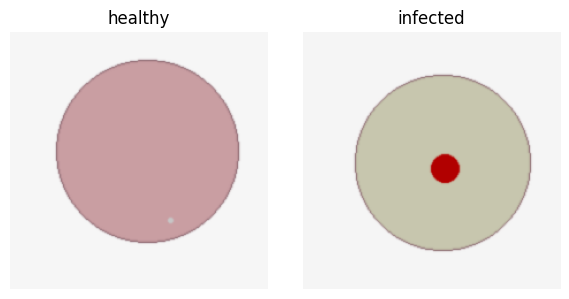

Train distribution: Counter({1: 209, 0: 205})


In [11]:
# Cell 13: show some samples and class counts
# display some images
sample_paths = []
for cls in class_names:
    p = next(Path(TRAIN_DIR).joinpath(cls).glob('*'))
    sample_paths.append(p)
imgs = [resize_pil(Image.open(p).convert("RGB"), IMG_SIZE) for p in sample_paths]
plot_grid(imgs, titles=class_names, cols=len(imgs), size=(3,3))

# class counts
from collections import Counter
counter = Counter()
for imgs, labels in train_ds.unbatch():
    counter[int(labels.numpy())] += 1
print("Train distribution:", counter)


In [12]:
# Cell 15: augmentation and preprocess
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomContrast(0.08)
], name='data_augmentation')

preprocess_input = tf.keras.applications.efficientnet.preprocess_input


In [13]:
# Cell 16: model builder
def build_model(img_size=IMG_SIZE, backbone='EfficientNetB0', dropout=0.3, lr=1e-3):
    if backbone == 'EfficientNetB0':
        base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(*img_size,3))
    else:
        base = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(*img_size,3))
    base.trainable = False

    inputs = keras.Input(shape=(*img_size,3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

model = build_model()
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                             

In [14]:
# Cell 18: callbacks and class weights
logdir = os.path.join(OUTPUT_DIR, "logs")
callbacks = [
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, "best_model.h5"), save_best_only=True, monitor='val_auc', mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-7),
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=6, mode='max', restore_best_weights=True),
    keras.callbacks.TensorBoard(log_dir=logdir)
]

# compute class weights
from collections import Counter
counter = Counter()
for imgs, labels in train_ds.unbatch():
    counter[int(labels.numpy())] += 1
total = sum(counter.values())
class_weights = {i: total/(len(counter)*count) for i,count in counter.items()}
print("Class weights:", class_weights)


Class weights: {1: 0.9904306220095693, 0: 1.0097560975609756}


Epoch 1/10
13/13 [==============================] - ETA: 0s - loss: 0.1347 - accuracy: 0.9420 - auc: 0.9900

C:\Users\saaar\anaconda3\envs\tf\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


13/13 [==============================] - 21s 1s/step - loss: 0.1347 - accuracy: 0.9420 - auc: 0.9900 - val_loss: 0.0308 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 0.0010
Epoch 2/10
13/13 [==============================] - 10s 803ms/step - loss: 0.0074 - accuracy: 0.9976 - auc: 1.0000 - val_loss: 0.0098 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 0.0010
Epoch 3/10
13/13 [==============================] - 28s 2s/step - loss: 0.0018 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0054 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 0.0010
Epoch 4/10
13/13 [==============================] - 34s 3s/step - loss: 0.0011 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0035 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 0.0010
Epoch 5/10
13/13 [==============================] - 34s 3s/step - loss: 9.0603e-04 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0026 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 5.0000e-04
Epoch 6/10
13/13 [==============================] - 38s 3s/step - loss: 0.0

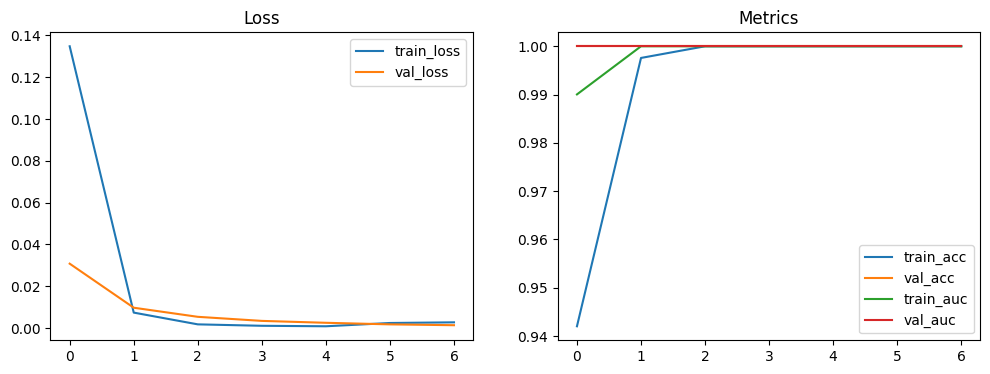

Saved model_initial.h5


In [15]:
# Cell 20: train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)
# plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss'); plt.plot(history.history['val_loss'], label='val_loss'); plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc'); plt.plot(history.history['val_accuracy'], label='val_acc')
if 'auc' in history.history:
    plt.plot(history.history['auc'], label='train_auc'); plt.plot(history.history['val_auc'], label='val_auc')
plt.legend(); plt.title('Metrics')
plt.show()

model.save(os.path.join(OUTPUT_DIR, "model_initial.h5"))
print("Saved model_initial.h5")


Base model identified: efficientnetb0
Epoch 1/5
13/13 [==============================] - 81s 4s/step - loss: 0.0040 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0190 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 2/5
13/13 [==============================] - 51s 4s/step - loss: 0.0016 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0124 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 3/5
13/13 [==============================] - 47s 4s/step - loss: 8.4241e-04 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0084 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 4/5
13/13 [==============================] - 46s 4s/step - loss: 9.4289e-04 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0054 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 5/5
13/13 [==============================] - 48s 4s/step - loss: 9.6773e-04 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.0038 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 5.0000e-06


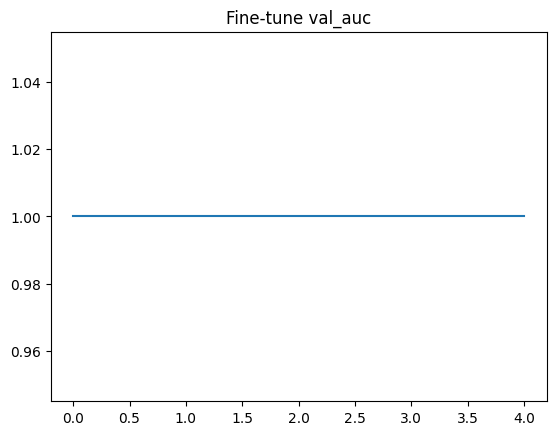

Saved model_finetuned.h5


In [16]:
# Cell 22: fine-tune
# find and unfreeze top layers of base
base_model = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and 'efficientnet' in layer.name:
        base_model = layer
        break
if base_model is None:
    # fallback: find first layer with many sublayers
    for layer in model.layers:
        if hasattr(layer, 'layers') and len(getattr(layer, 'layers'))>20:
            base_model = layer
            break
print("Base model identified:", getattr(base_model, 'name', 'unknown'))

base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.6)
for l in base_model.layers[:fine_tune_at]:
    l.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=FINE_TUNE_EPOCHS, callbacks=callbacks, class_weight=class_weights)
plt.plot(history_ft.history.get('val_auc', [])); plt.title('Fine-tune val_auc'); plt.show()

model.save(os.path.join(OUTPUT_DIR, "model_finetuned.h5"))
print("Saved model_finetuned.h5")


1/1 [==============================] - 5s 5s/step
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        51
    infected       1.00      1.00      1.00        41

    accuracy                           1.00        92
   macro avg       1.00      1.00      1.00        92
weighted avg       1.00      1.00      1.00        92

Confusion matrix:
 [[51  0]
 [ 0 41]]


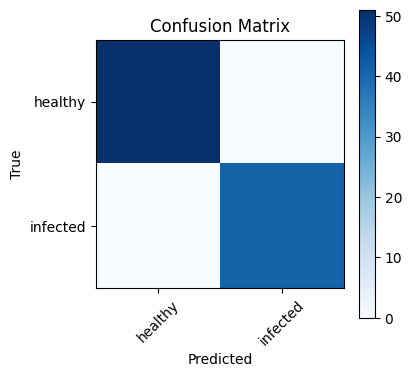

ROC AUC: 1.0
Precision (classwise): [1. 1.]
Recall (classwise; sensitivity): [1. 1.]
F1 (classwise): [1. 1.]


In [17]:
 # Cell 24: evaluation
y_true = []
y_prob = []
for imgs, labels in test_ds:
    preds = model.predict(imgs)
    y_true.extend(labels.numpy().astype(int).tolist())
    y_prob.extend(preds.ravel().tolist())

y_pred = [1 if p >= 0.5 else 0 for p in y_prob]

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues'); plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()

auc = roc_auc_score(y_true, y_prob)
print("ROC AUC:", auc)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0,1])
print("Precision (classwise):", precision)
print("Recall (classwise; sensitivity):", recall)
print("F1 (classwise):", f1)


In [18]:
def find_last_conv_layer(model):
    # fallback automatic detection
    for layer in reversed(model.layers):
        if hasattr(layer, "output_shape") and len(layer.output_shape) == 4:
            return layer.name
    return None

# Force correct layer for EfficientNet
try:
    last_conv = model.get_layer("top_conv").name
except:
    last_conv = find_last_conv_layer(model)

print("Using last conv layer:", last_conv)


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Build a model that maps input → activations + predictions
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() != 0:
        heatmap /= heatmap.max()
    else:
        heatmap = np.zeros_like(heatmap)

    return heatmap


Using last conv layer: efficientnetb0


In [19]:
# Cell 28: TF-Lite conversion
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    tflite_path = os.path.join(OUTPUT_DIR, "malaria_model_dynamic.tflite")
    with open(tflite_path, "wb") as f:
        f.write(tflite_model)
    print("Saved TF-Lite model to", tflite_path)
except Exception as e:
    print("TF-Lite conversion failed:", e)


INFO:tensorflow:Assets written to: C:\Users\saaar\AppData\Local\Temp\tmph60sbzji\assets


INFO:tensorflow:Assets written to: C:\Users\saaar\AppData\Local\Temp\tmph60sbzji\assets


Saved TF-Lite model to outputs\malaria_model_dynamic.tflite


In [20]:
# Cell 30: write flask_example.py
flask_code = r"""
from flask import Flask, request, jsonify
import numpy as np
from PIL import Image
import io
import tensorflow as tf

app = Flask(__name__)
model = tf.keras.models.load_model('outputs/model_finetuned.h5')

def preprocess_image_bytes(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((224,224))
    arr = np.array(img).astype('float32')
    arr = tf.keras.applications.efficientnet.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

@app.route('/predict', methods=['POST'])
def predict():
    file = request.files.get('image')
    if file is None:
        return jsonify({'error': 'no image received'}), 400
    img = preprocess_image_bytes(file.read())
    prob = float(model.predict(img)[0,0])
    label = 'infected' if prob >= 0.5 else 'healthy'
    return jsonify({'label': label, 'probability': prob})

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
"""
open(os.path.join(OUTPUT_DIR, "flask_example.py"), "w").write(flask_code)
print("Wrote outputs/flask_example.py")


Wrote outputs/flask_example.py
